In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import metrics
import mglearn


Size of the training set : (112, 4)
Size of the testing set: (38, 4)


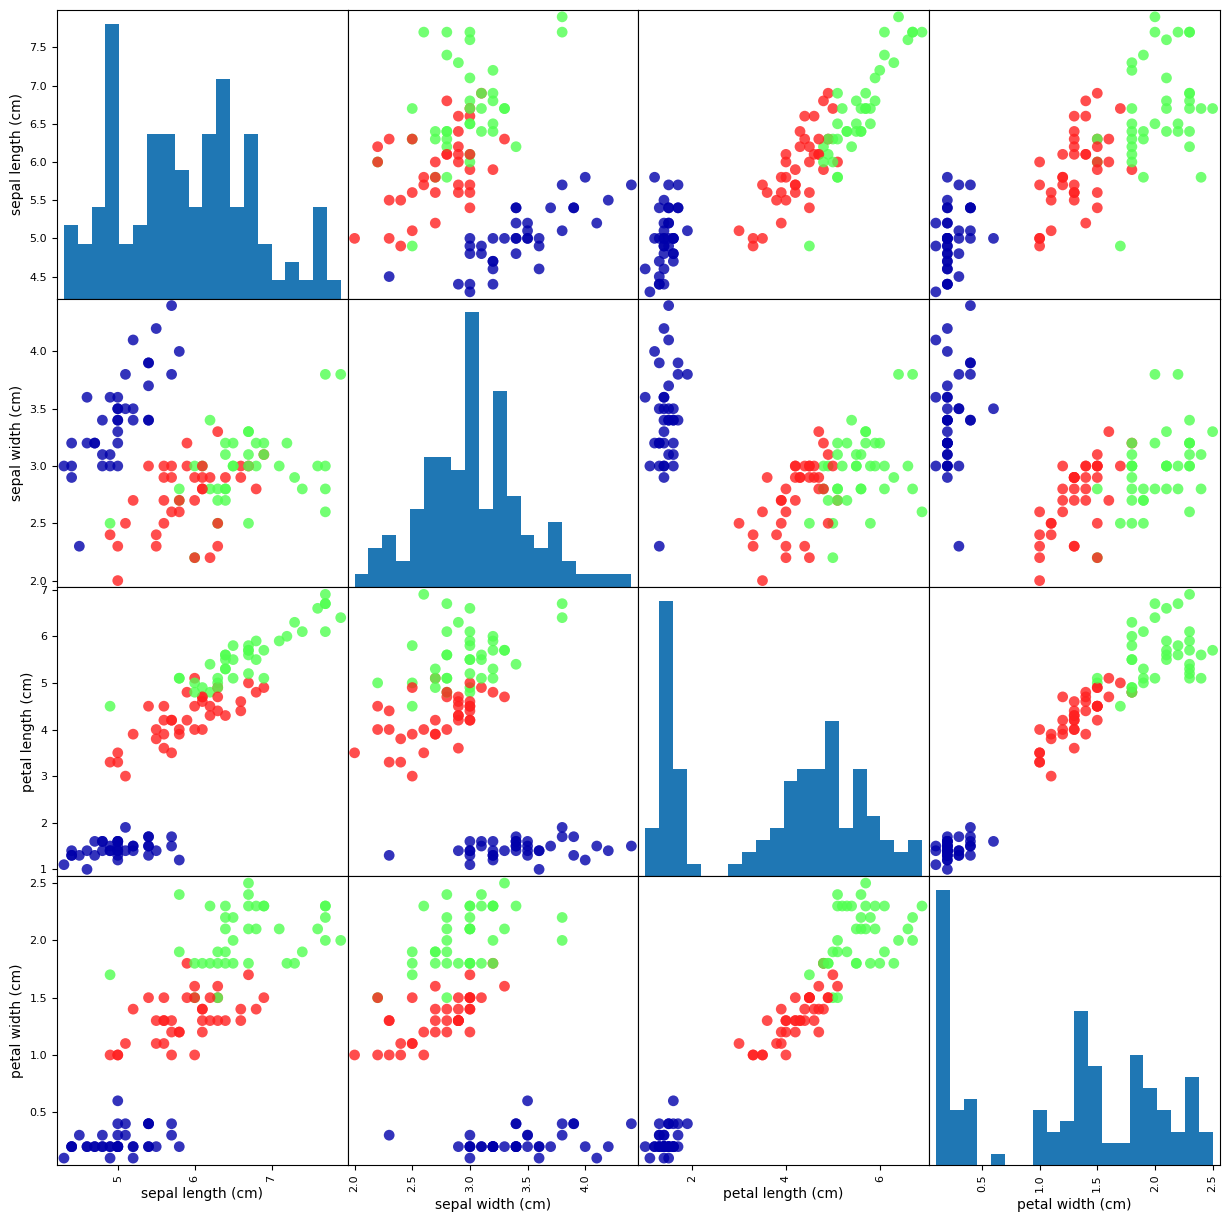

In [4]:
iris = load_iris()

x_trn, x_tst, y_trn, y_tst = train_test_split(iris['data'], iris['target'], stratify=iris['target'], random_state=0)
print("Size of the training set :", x_trn.shape)
print("Size of the testing set:", x_tst.shape)


import pandas as pd
iris_dataframe = pd.DataFrame(x_trn, columns=iris.feature_names)
grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_trn, figsize=(15, 15), marker='o',
 hist_kwds={'bins': 20}, s=60, alpha=.8, cmap=mglearn.cm3)

#display(mglearn.plots.plot_tree_progressive())


feature0 - mean=5.866071428571429 - std=0.8566497837744526
feature1 - mean=3.039285714285714 - std=0.4518527618233034
feature2 - mean=3.7705357142857143 - std=1.7858390581409156
feature3 - mean=1.2098214285714286 - std=0.7606341129784613
feature0 - mean=5.866071428571429 - std=0.8566497837744526
feature1 - mean=3.039285714285714 - std=0.4518527618233034
feature2 - mean=3.7705357142857143 - std=1.7858390581409156
feature3 - mean=1.2098214285714286 - std=0.7606341129784613


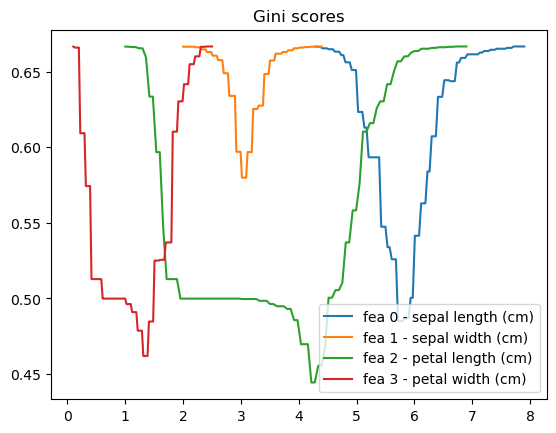

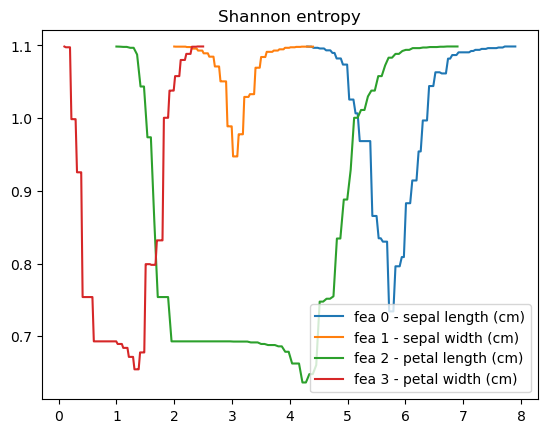

In [63]:
def gini_impurity (classes):
    nbData = classes.shape[0]
    if nbData <= 10:
        return 0.5 
    p_sum = 0
    for idx in np.unique( classes ):
        classCounts = np.sum( classes == idx)
        p_sum = p_sum  +  (classCounts / nbData ) * (classCounts / nbData ) 
    gini = 1 - p_sum
    return gini

def shannon_entroty (classes):
    nbData = classes.shape[0]
    if nbData <= 10:
        return 0.5
    entropy = 0
    for idx in np.unique( classes ):
        classCounts = np.sum( classes == idx)
        if classCounts > 0 :
            entropy -= (classCounts / nbData ) * np.log(classCounts / nbData )
    return entropy

nbVal=100

plt.figure(0)
for fea in range(4):#range(x_trn.shape[1]):
    print('feature' + str(fea) + ' - mean='+ str(np.mean(x_trn[:,fea]))+ ' - std='+ str(np.std(x_trn[:,fea])))
    scores = np.zeros(nbVal)
    feaVal = np.linspace( np.min(x_trn[:,fea]) , np.max(x_trn[:,fea]) , nbVal )
    for idx in range(nbVal):
        classes0 = y_trn[x_trn[:,fea]<feaVal[idx]]
        classes1 = y_trn[x_trn[:,fea]>=feaVal[idx]]
        score0 = gini_impurity( classes0 )
        score1 = gini_impurity( classes1 )
        scores[idx] = np.max([score0 , score1])
    plt.plot(feaVal,scores)
    plt.plot()
plt.title('Gini scores')
plt.legend(['fea 0 - ' + str(iris.feature_names[0]), 'fea 1 - ' + str(iris.feature_names[1]), 'fea 2 - ' + str(iris.feature_names[2]), 'fea 3 - ' + str(iris.feature_names[3])])

plt.figure(1)
for fea in range(4):#range(x_trn.shape[1]):
    print('feature' + str(fea) + ' - mean='+ str(np.mean(x_trn[:,fea]))+ ' - std='+ str(np.std(x_trn[:,fea])))
    scores = np.zeros(nbVal)
    feaVal = np.linspace( np.min(x_trn[:,fea]) , np.max(x_trn[:,fea]) , nbVal )
    for idx in range(nbVal):
        classes0 = y_trn[x_trn[:,fea]<feaVal[idx]]
        classes1 = y_trn[x_trn[:,fea]>=feaVal[idx]]
        score0 = shannon_entroty( classes0 )
        score1 = shannon_entroty( classes1 )
        scores[idx] = np.max([score0 , score1])
    plt.plot(feaVal,scores)
    plt.plot()
plt.title('Shannon entropy')
plt.legend(['fea 0 - ' + str(iris.feature_names[0]), 'fea 1 - ' + str(iris.feature_names[1]), 'fea 2 - ' + str(iris.feature_names[2]), 'fea 3 - ' + str(iris.feature_names[3])])


sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 0.0
petal width (cm) : 1.0


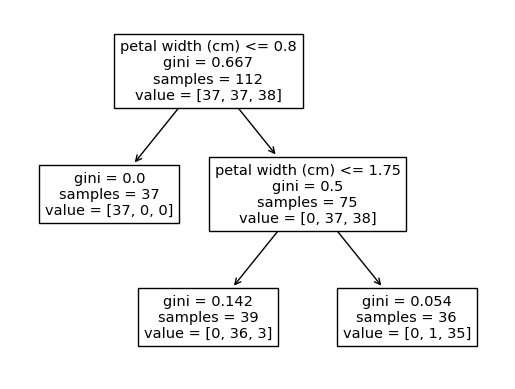

In [43]:

T = tree.DecisionTreeClassifier(max_depth=2, random_state=0)
T = T.fit(x_trn, y_trn)

tree.plot_tree(T, feature_names=iris['feature_names'])

for i in range(0,4):
    print(iris.feature_names[i], ":", T.feature_importances_[i])


sepal length (cm) : 0.017858566531132904
sepal width (cm) : 0.0
petal length (cm) : 0.029556581768971135
petal width (cm) : 0.952584851699896


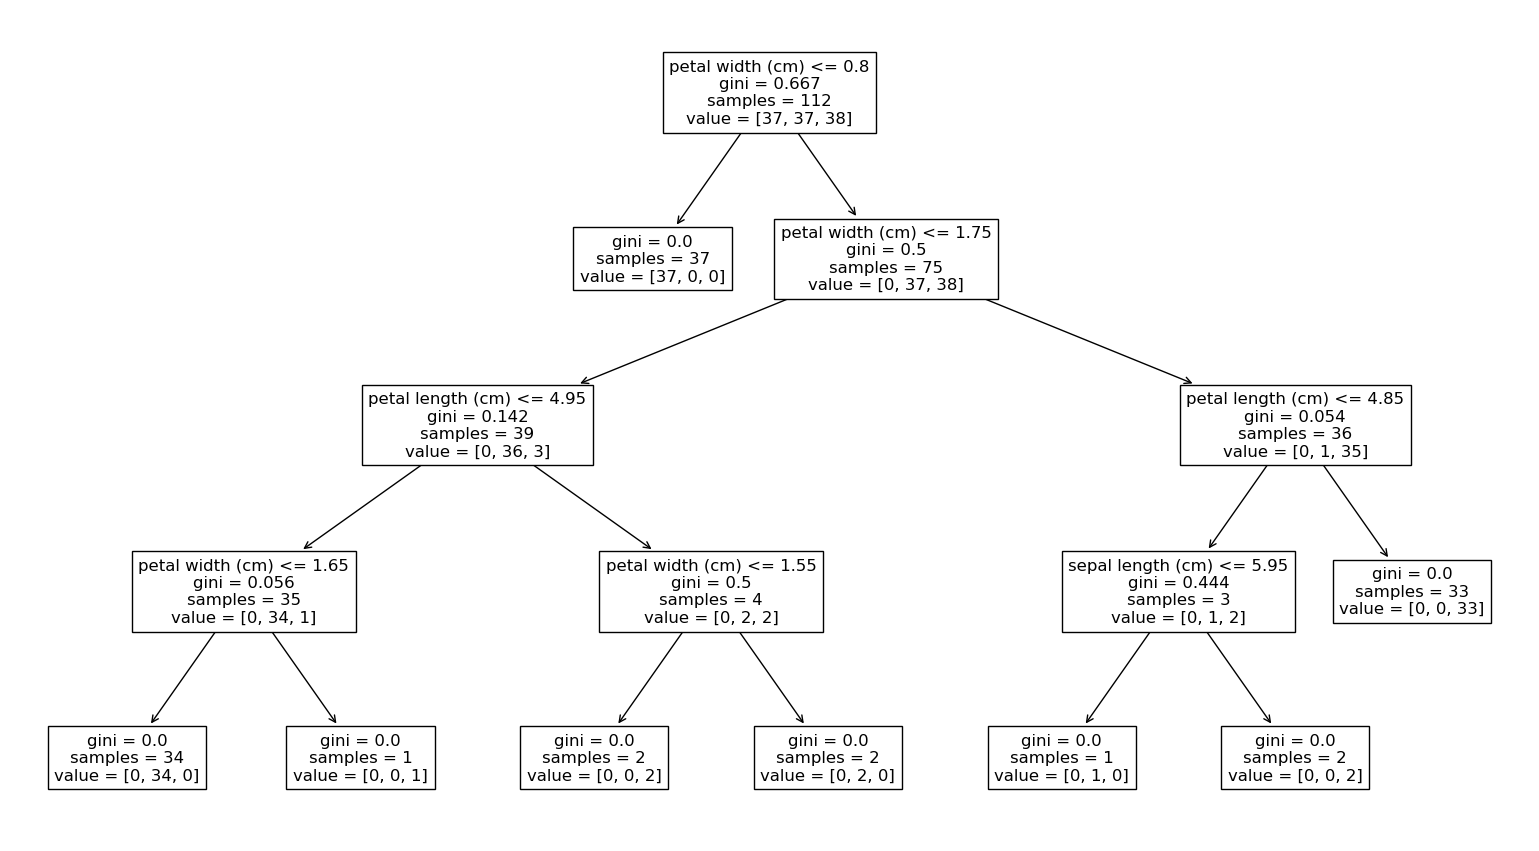

In [67]:
T = tree.DecisionTreeClassifier(max_depth=4, random_state=0)
T = T.fit(x_trn, y_trn)

_, ax = plt.subplots(figsize=(19.60,10.80)) # Resize figure
tree.plot_tree(T, feature_names=iris['feature_names'], ax=ax)

for i in range(0,4):
    print(iris.feature_names[i], ":", T.feature_importances_[i])


0.0

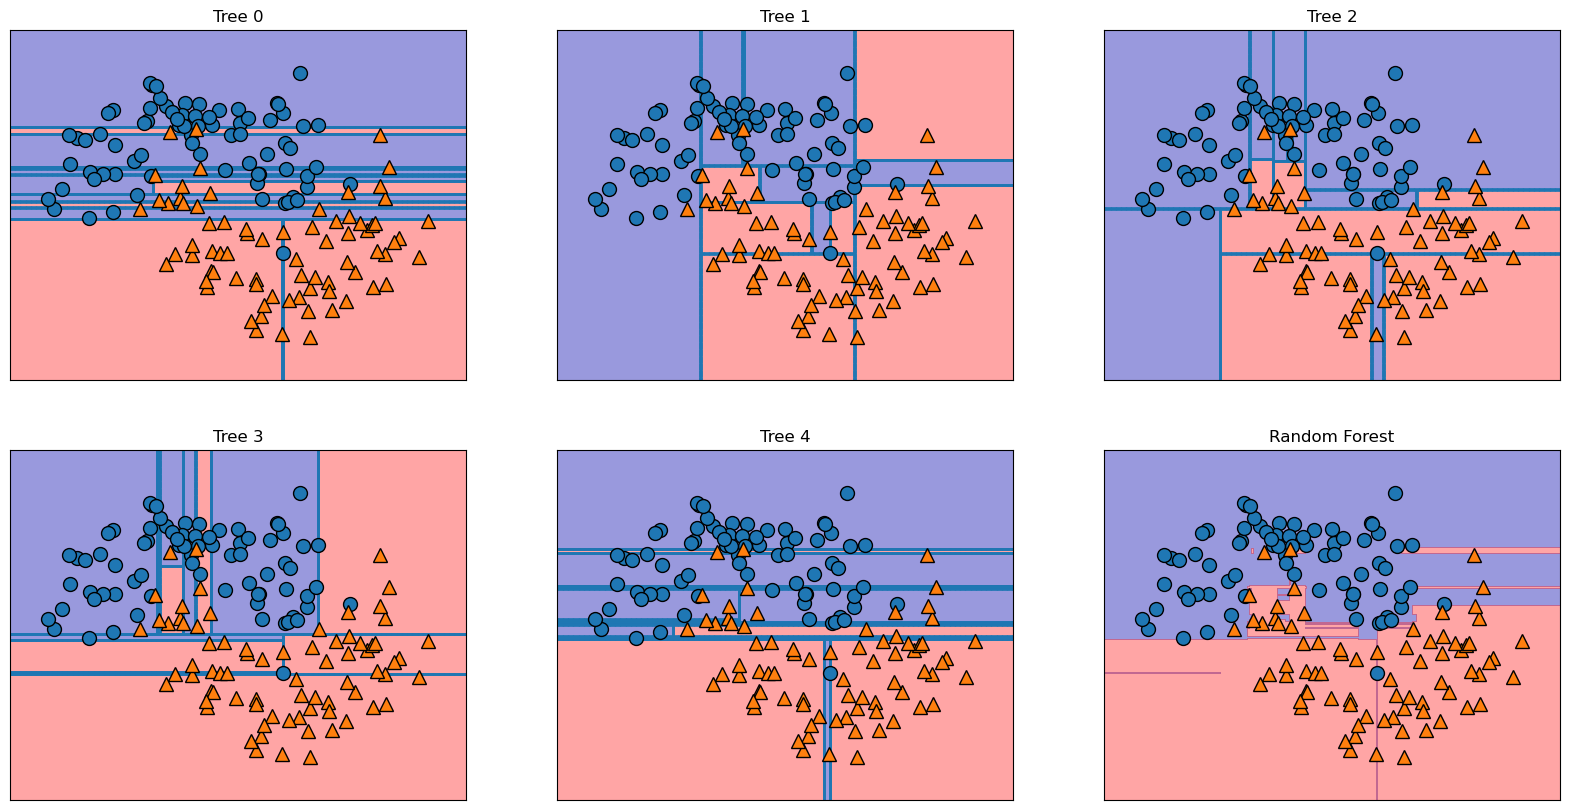

In [73]:
from sklearn.ensemble import RandomForestClassifier
X, y = sklearn.datasets.make_moons(n_samples=200, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train, y_train)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)

mglearn.plots.plot_2d_separator(forest, X_train, fill=True, ax=axes[-1, -1],alpha=.4)
axes[-1, -1].set_title("Random Forest")
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)